In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os 
os.chdir('..')

In [3]:
import torch
from sklearn.model_selection import train_test_split
from fq_model.fq_pre_train import FQ_regression
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, mean_squared_error
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [4]:
from regression.cal_house.cal_housing import CalHousing
X, y = CalHousing().get_data()

In [5]:
X.std(axis=0)

array([0.19955467, 0.22702395, 0.2468921 , 0.05557801, 0.06539025,
       0.03176044, 0.06286628, 0.13098059, 0.35502503])

In [6]:
y.std()

0.2380048790064407

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
print(device)
test_size=0.2
batch_size=400
random_state=17
num_epochs=100
rules=3
lr=0.0005

cuda


In [8]:

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.5,
                                                    random_state=random_state)
    
out_size = 1
print('out_size', out_size)
model = FQ_regression(in_features=X.shape[1],
                      rules=rules,
                      out_features=out_size,
                      device=device).to(device)

# model._rule_initialization(X_train, y_train)


X_train_eval = X_train
X_test_eval = X_test
y_train_eval = y_train
y_test_eval = y_test

X_train = torch.Tensor(X_train).to(device)
X_test = torch.Tensor(X_test).to(device)
y_train = torch.Tensor(y_train).to(device)
y_test = torch.Tensor(y_test).to(device)


out_size 1


In [9]:
import torch.nn as nn

# Set up optimizer and loss function for pre-training
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# Pre-training loop
num_epochs_pretrain = 400
model.train()
for epoch in range(num_epochs_pretrain):
    total_loss = 0
    for i in range(0, len(X_train), batch_size):
        optimizer.zero_grad()
        batch_X = X_train[i:i+batch_size]
        reconstructed_X = model(batch_X, phase='pretrain')
        loss = loss_fn(reconstructed_X, batch_X)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'Epoch {epoch+1}, Pre-training Loss: {total_loss / len(X_test)}')


Epoch 1, Pre-training Loss: 0.0003932169549698768
Epoch 2, Pre-training Loss: 0.00031107093774608476
Epoch 3, Pre-training Loss: 0.00025037952329683784
Epoch 4, Pre-training Loss: 0.000205628428047763
Epoch 5, Pre-training Loss: 0.00017271102024604164
Epoch 6, Pre-training Loss: 0.0001484707334777363
Epoch 7, Pre-training Loss: 0.0001308243720629706
Epoch 8, Pre-training Loss: 0.0001180135949700852
Epoch 9, Pre-training Loss: 0.00010854793969369325
Epoch 10, Pre-training Loss: 0.00010144817409968556
Epoch 11, Pre-training Loss: 9.603195933022937e-05
Epoch 12, Pre-training Loss: 9.178699778054364e-05
Epoch 13, Pre-training Loss: 8.832540713470136e-05
Epoch 14, Pre-training Loss: 8.53742118875633e-05
Epoch 15, Pre-training Loss: 8.273194391334011e-05
Epoch 16, Pre-training Loss: 8.025263450996767e-05
Epoch 17, Pre-training Loss: 7.785837891325391e-05
Epoch 18, Pre-training Loss: 7.559514236337018e-05
Epoch 19, Pre-training Loss: 7.348569554686138e-05
Epoch 20, Pre-training Loss: 7.144530

In [10]:
train_loss = []
test_loss = []

num_epochs=2000

# Initialize Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)

# Store initial parameters
initial_params = {name: param.clone().detach() for name, param in model.named_parameters()}


for epoch in range(num_epochs):
    model.train()
    for i in range(0, len(X_train), batch_size):
    # for i in range(1):
        optimizer.zero_grad()
        batch_X, batch_y = X_train[i:i+batch_size], y_train[i:i+batch_size]
        outputs = model(batch_X)
        mse_loss = F.mse_loss(outputs, batch_y)
        total_loss = mse_loss  
        total_loss.backward()
        # print(model.tt.grad[0][0][0])
        optimizer.step()

    model.eval()
    with torch.no_grad():
        outputs = model(X_test).cpu()
        mse_loss = mean_squared_error(y_test_eval, outputs, squared=False)
        total_loss = mse_loss
        test_loss.append(total_loss.item())
        #####
        outputs = model(X_train).cpu()
        mse_loss = mean_squared_error(y_train_eval, outputs, squared=False)
        total_loss = mse_loss
        train_loss.append(total_loss.item())


# train_loss = np.sqrt(train_loss)
# test_loss = np.sqrt(test_loss)

# Calculate and print the average accuracy across all folds
min_RMSE = min(test_loss)
print("minimum test RMSE:", min_RMSE)
min_RMSE = min(train_loss)
print("minimum train RMSE:", min_RMSE)

minimum test RMSE: 0.1255465511658694
minimum train RMSE: 0.12173447432349416


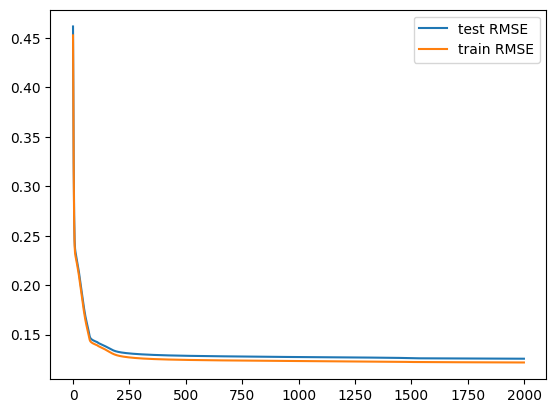

In [11]:
plt.plot(np.arange(len(test_loss)), test_loss)
plt.plot(np.arange(len(train_loss)), train_loss)
plt.legend(['test RMSE', 'train RMSE'])
plt.show()

In [12]:
initial_params.items()

dict_items([('mean', tensor([[[ 0.9121,  0.8447,  1.0580],
         [-0.0373,  0.0642,  1.1176],
         [-0.0927,  1.2066, -0.0614],
         [ 0.7229,  0.7240,  0.8982],
         [ 0.1932,  0.5982,  0.7793],
         [ 0.0893,  0.9635,  0.9007],
         [ 0.7279,  0.6194,  0.8083],
         [-0.0473,  0.0374,  0.7849],
         [ 1.1688,  0.3537, -0.1583]]], device='cuda:0')), ('std', tensor([[[ 7.2456e-01,  2.5243e-04,  7.8096e-01],
         [ 1.0331e-02,  9.8563e-01,  1.0707e+00],
         [ 2.7700e-02,  8.2031e-01,  9.5646e-01],
         [ 3.1465e-02,  3.5171e-02,  4.7604e-01],
         [ 2.6895e-01,  5.2260e-01,  1.5395e-01],
         [ 1.0354e+00,  3.7293e-01,  8.8938e-01],
         [ 1.7579e-01,  3.9005e-01,  9.9940e-01],
         [ 4.7168e-01,  4.1972e-01, -3.8846e-04],
         [ 1.4877e+00,  9.0232e-03,  6.7645e-01]]], device='cuda:0')), ('tt', tensor([[[-3.1185e-01, -1.2820e-01, -9.2432e-01],
         [-4.6009e-01,  3.8592e-01,  1.0517e+00],
         [-2.3522e-01,  9.6019

In [13]:
updated_params = {name: param.clone().detach() for name, param in model.named_parameters()}
updated_params

{'mean': tensor([[[ 0.9560,  0.8447,  0.9826],
          [-0.0326,  0.1002,  1.3117],
          [-0.0294,  1.0747, -0.0293],
          [ 0.7154,  0.7752,  0.5496],
          [ 0.1120,  0.9997,  0.2913],
          [-0.0765,  0.6539,  0.7393],
          [ 0.7269,  0.7529,  0.7786],
          [-0.0238,  0.6395,  0.7849],
          [ 0.9779,  0.3537,  0.0089]]], device='cuda:0'),
 'std': tensor([[[ 7.2161e-01,  2.5243e-04,  7.2690e-01],
          [ 3.9395e-02,  1.5196e-01,  7.5368e-01],
          [ 5.9738e-03,  1.1923e+00,  5.8451e-01],
          [ 9.1143e-03,  4.2387e-02,  7.1459e-01],
          [ 9.8408e-02,  9.1229e-03,  3.2318e-01],
          [ 6.6927e-02,  5.4611e-01,  8.8898e-01],
          [ 2.1173e-03,  8.1884e-03,  8.7939e-01],
          [ 5.1672e-01,  2.2673e-01, -3.8846e-04],
          [ 1.8512e+00,  9.0232e-03,  5.3887e-01]]], device='cuda:0'),
 'tt': tensor([[[-1.0508,  0.1029,  0.5490],
          [-0.4788, -0.5438,  2.1809],
          [-0.2759, -2.3627, -0.6549],
          [-

In [14]:
# After training, you can get the updated parameters
updated_params = {name: param.clone().detach() for name, param in model.named_parameters()}

# # Calculate the difference between initial and updated parameters
# param_diff = {name: updated - initial for name, (updated, initial) in zip(updated_params.items(), initial_params.items())}

# Print the difference
for name, updated in updated_params.items():
    print(name)
    print(updated - initial_params[name])

mean
tensor([[[ 0.0439,  0.0000, -0.0754],
         [ 0.0047,  0.0361,  0.1941],
         [ 0.0633, -0.1319,  0.0320],
         [-0.0076,  0.0512, -0.3486],
         [-0.0812,  0.4015, -0.4880],
         [-0.1659, -0.3096, -0.1614],
         [-0.0010,  0.1335, -0.0298],
         [ 0.0236,  0.6021,  0.0000],
         [-0.1909,  0.0000,  0.1672]]], device='cuda:0')
std
tensor([[[-2.9467e-03,  0.0000e+00, -5.4062e-02],
         [ 2.9064e-02, -8.3368e-01, -3.1707e-01],
         [-2.1726e-02,  3.7199e-01, -3.7194e-01],
         [-2.2351e-02,  7.2155e-03,  2.3855e-01],
         [-1.7054e-01, -5.1347e-01,  1.6923e-01],
         [-9.6844e-01,  1.7318e-01, -4.0442e-04],
         [-1.7368e-01, -3.8186e-01, -1.2001e-01],
         [ 4.5049e-02, -1.9300e-01,  0.0000e+00],
         [ 3.6351e-01,  0.0000e+00, -1.3758e-01]]], device='cuda:0')
tt
tensor([[[-0.7389,  0.2311,  1.4733],
         [-0.0187, -0.9297,  1.1292],
         [-0.0407, -2.4587, -0.5528],
         [-0.0407,  0.3437,  0.0816],
      

In [15]:
model.mean

Parameter containing:
tensor([[[ 0.9560,  0.8447,  0.9826],
         [-0.0326,  0.1002,  1.3117],
         [-0.0294,  1.0747, -0.0293],
         [ 0.7154,  0.7752,  0.5496],
         [ 0.1120,  0.9997,  0.2913],
         [-0.0765,  0.6539,  0.7393],
         [ 0.7269,  0.7529,  0.7786],
         [-0.0238,  0.6395,  0.7849],
         [ 0.9779,  0.3537,  0.0089]]], device='cuda:0', requires_grad=True)

In [16]:
torch.tanh(model.tt)

tensor([[[-0.7821,  0.1026,  0.4998],
         [-0.4452, -0.4958,  0.9748],
         [-0.2691, -0.9824, -0.5750],
         [-0.2180,  0.1355,  0.0825],
         [ 0.3280,  0.3520, -0.7143],
         [ 0.7891,  0.3396,  0.8898],
         [-0.0577,  0.2515, -0.7978],
         [-0.7379, -0.6021,  0.0378],
         [-0.4332, -0.0272,  0.2293]]], device='cuda:0',
       grad_fn=<TanhBackward0>)

In [17]:
model.linear.weight

AttributeError: 'FQ_regression' object has no attribute 'linear'

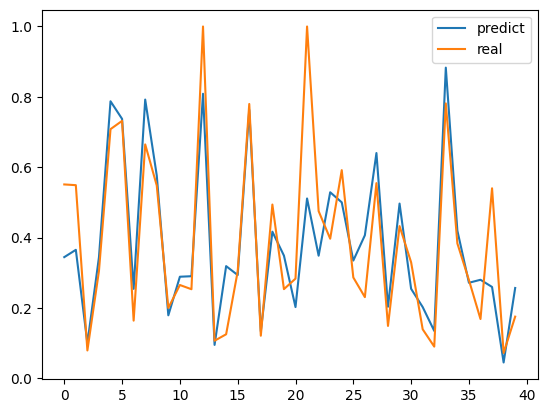

In [ ]:
model.eval()
with torch.no_grad():
    plt.plot(np.array(model(X_test).to('cpu'))[40:80])
    plt.plot(y_test.cpu()[40:80])
    plt.legend(['predict', 'real'])

In [ ]:
np.sqrt(mean_squared_error(np.array(model(X_test).detach().to('cpu')), y_test.cpu()))

0.13040848

IRIS = 94</br>
Cryotheraphy = 95</br>
Immunotherapy = 89</br>
Haberman = 74</br>
Wine = 89</br>
heart = 85</br>
CAL HOUSING : tsk:0.34, mamdani=0.33